# Polarization Skewness Study
Toy box models simulating magnetic fields and turbulence to understand the polarization distribution skewness as a function of the Alfvenic Mach number.  

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from magnetic_fields import simulate_field, compute_S
# from plotting_functions import plot_comparison, plot_P_distributions, run_skewness_sweep, plot_synthetic_pol_maps, plot_pol_distributions
import plotting_functions as pf
from scipy.stats import skew, skewnorm


## Step 1 — Visual Check: P and PA maps

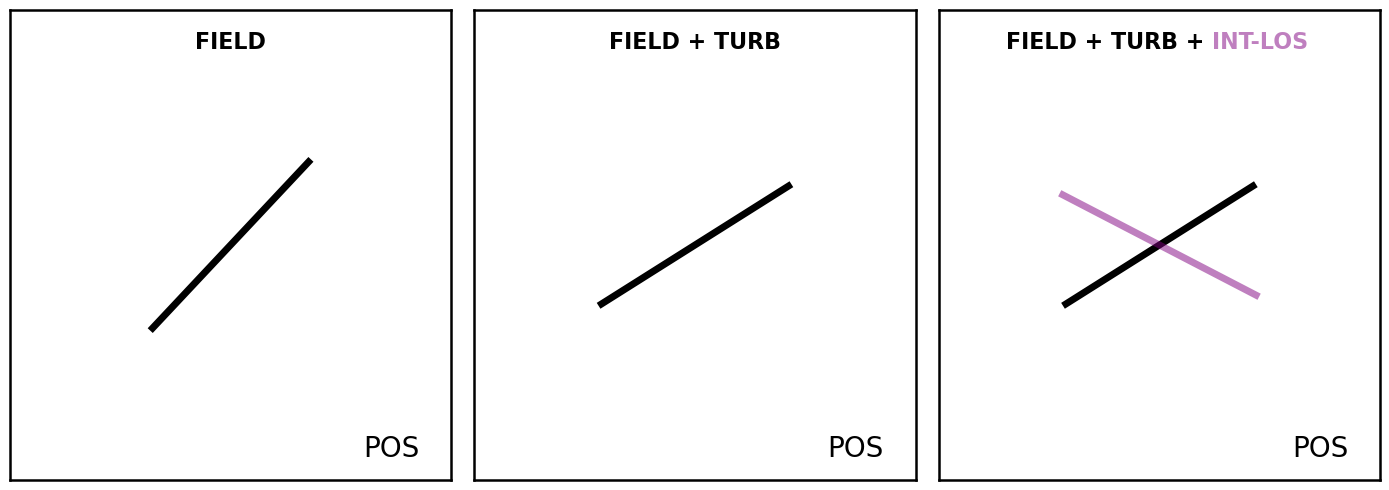

In [2]:
pf.LOS_contrib_visual()

# Step 2 — Show GS95 Model

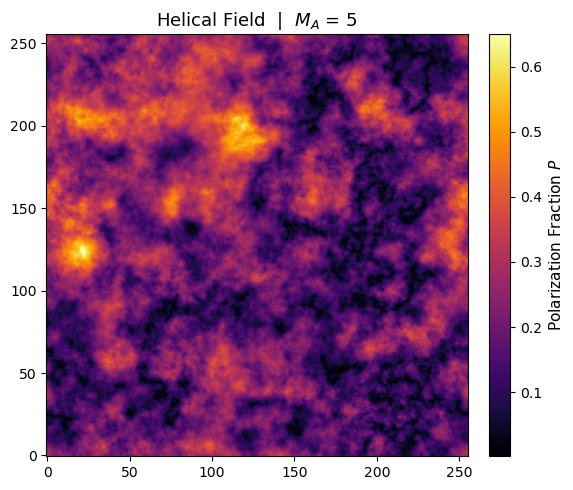


  Mean P : 0.2049
  Std  P  : 0.1024


In [3]:
"""
geometry options: 'uniform', 'wavy', 'helical', 'hourglass'
turbulence options: 'random', 'kolmogorov', 'gs95'
optional inputs: 
      iaxis (0,1,2) -- for non-symmetrical fields, look down various axes
      alpha (0-90) -- for helical fields, the angle of the helix, for uniform field, angle in POS, not required for hourglass or wavy fields
"""

# pf.plot_model_comparison(geometry     = 'helical',
#                 turbulence_a = 'kolmogorov',
#                 turbulence_b = 'gs95',
#                 iaxis=1, alpha=0, M_A=0.5, g_size=256)

pf.plot_gs95_turb_model(geometry = 'helical', turbulence='gs95', M_A=5, alpha=0, iaxis=1, g_size=256)

# Step 3 — Synthetic Polarization Map for each Geometry
 - M_A = 0.5

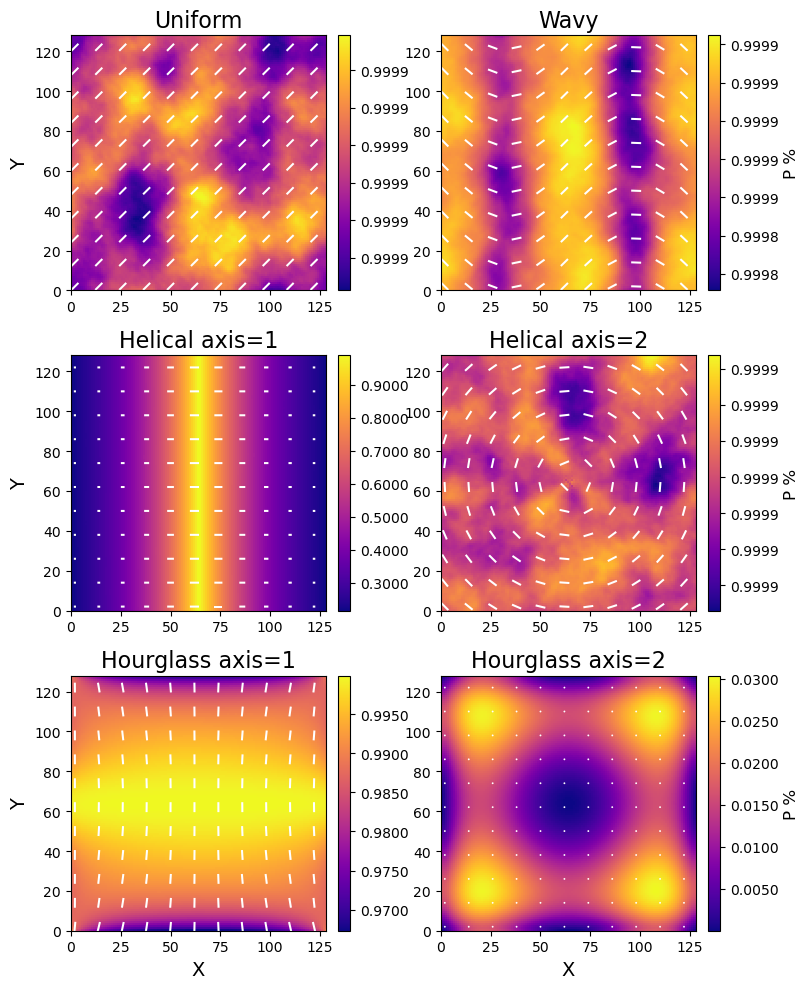

In [2]:
pf.plot_synthetic_pol_maps(M_A = 0.01, g_size=128, step=12, vscale=0.2)

# Step 4 — P Distributions as a function of M_A

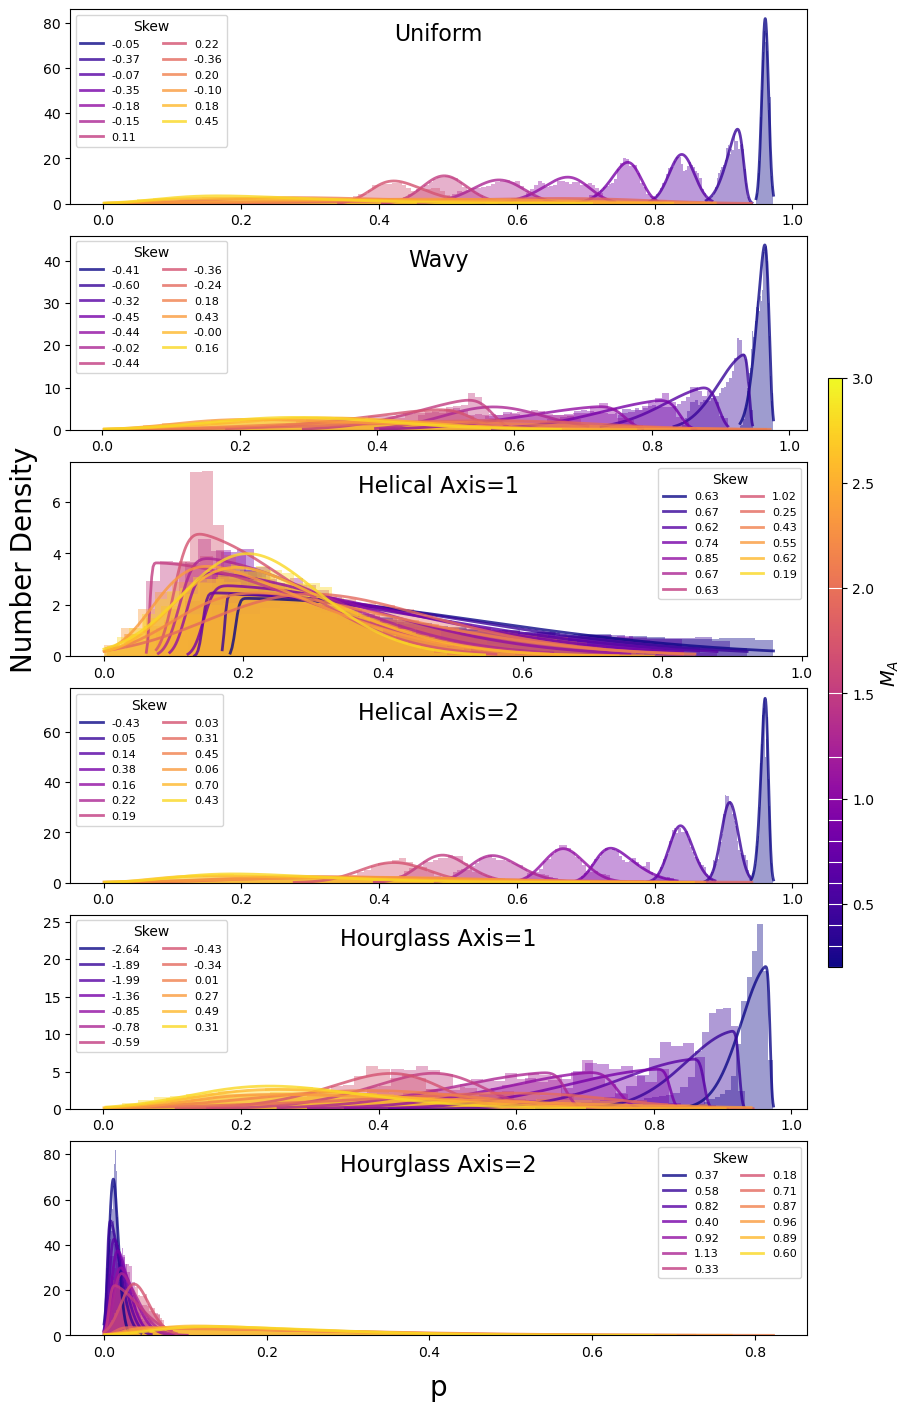

In [2]:
# mach_vals, skews = pf.plot_P_dist(geometry='hourglass', turbulence='gs95', alpha=0, iaxis=2, g_size=256, mach_vals = None)

pf.plot_pol_distributions()

# Step 5 — Run P% and PA comparisons

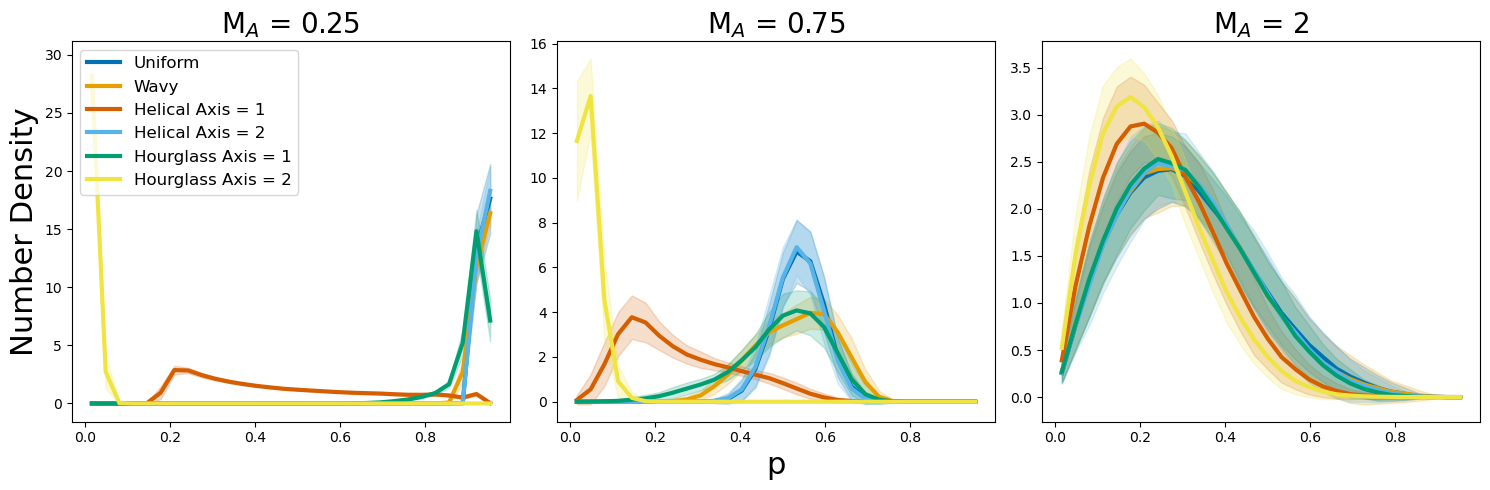

In [3]:
pf.plot_pol_comparisons(nruns=100, gsize=64)

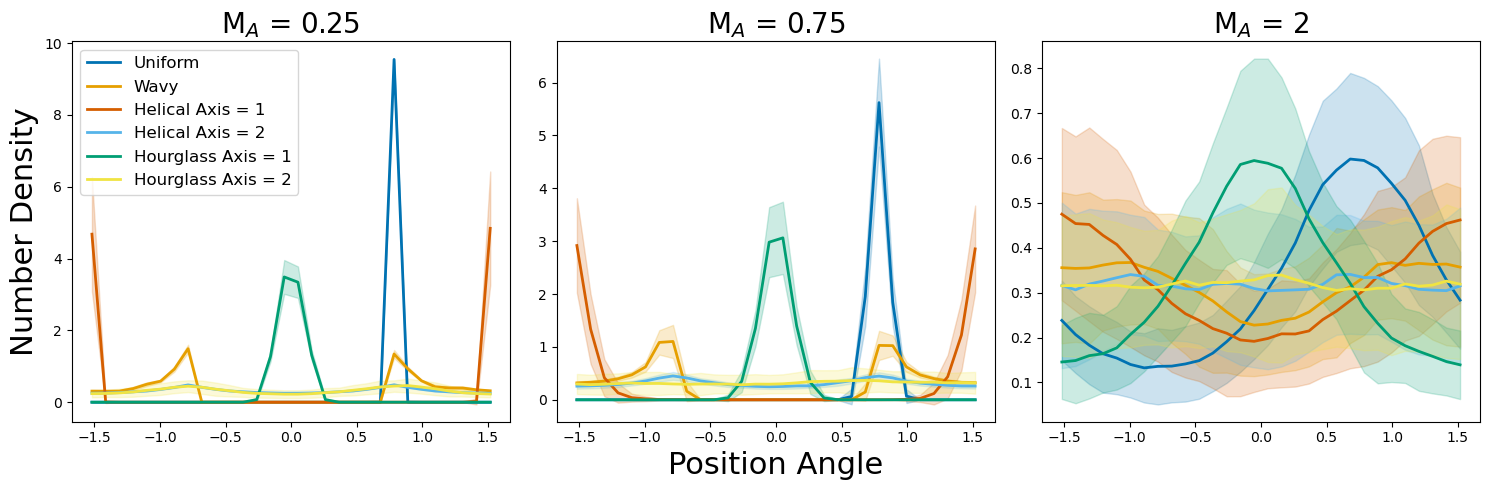

In [4]:
pf.plot_PA_comparisons(nruns=100, gsize=64)

# Step 6 — P% Skewness with M_A

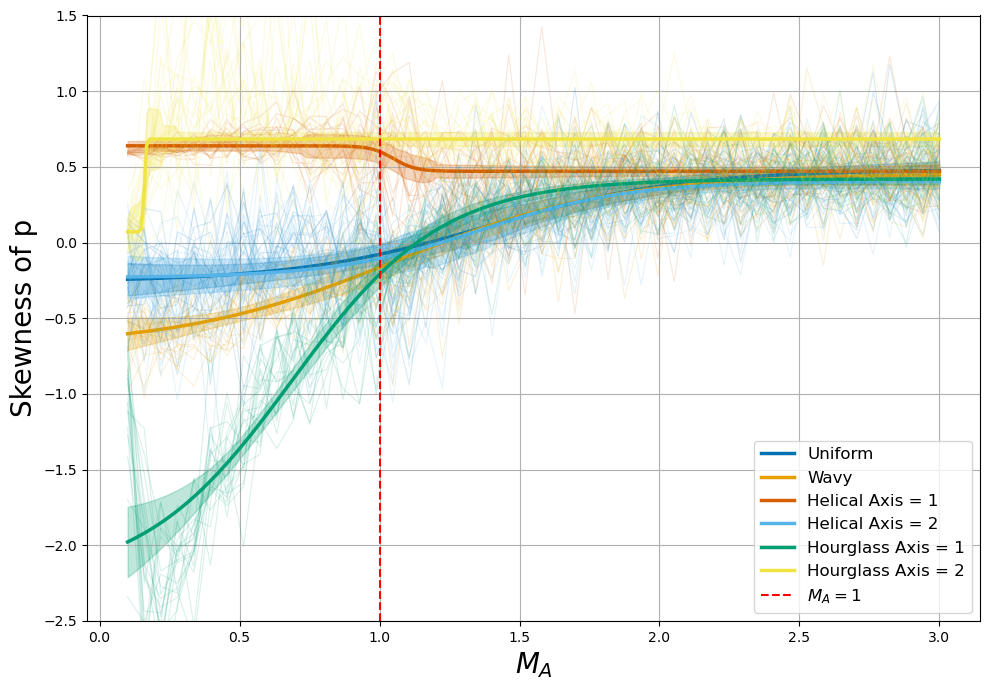

In [5]:
pf.plot_skewness_trendlines()

In [ ]:
# # run_skewness_sweep(geometry='helical', turbulence='gs95', alpha=0, iaxis=2, g_size=64, n_runs=50, mach_vals=None, 
# #                   fit_method='recip', color='blue', label=None)

# plt.figure(figsize=(10, 8))

# pf.run_skewness_sweep(geometry='helical', turbulence='gs95', alpha=0, iaxis = 2, g_size=64, n_runs=10, 
#                    fit_method='tanh', color='blue',  label=r'GS95 $\pm1\sigma$')

# pf.run_skewness_sweep(geometry='helical', turbulence='gs95', alpha=0, iaxis = 1, g_size=64, n_runs=10, 
#                    fit_method='tanh', color='green',  label=r'GS95 $\pm1\sigma$')

# # pf.run_skewness_sweep(geometry='helical', turbulence='kolmogorov', g_size=64, n_runs=50,
# #                    fit_method='tanh', color='purple',   label=r'Kolmo $\pm1\sigma$')

# # pf.run_skewness_sweep(geometry='helical', turbulence='random', g_size=64, n_runs=50,
# #                    fit_method='tanh', color='red',   label=r'Random $\pm1\sigma$')

# plt.xlabel(r'$M_A$', fontsize=20)
# plt.ylabel('Skewness of $P$', fontsize=20)
# plt.grid(True)
# plt.legend(loc='lower right', fontsize=13)
# plt.tight_layout()
# plt.show()

# Step 7 — Circular Variance of PA with M_A at various Noise levels

In [6]:
from collections import defaultdict

NOISE_VALS = [0.0, 0.005, 0.01, 0.02, 0.05, 0.10]
M_A_VALS  = np.linspace(0.05, 3.0, 20)
N_TRIALS  = 1       # number of noise realizations per M_A point
GSIZE     = 256
ALPHA     = 0
BLOS      = 5.0      # uG
TURB      = 'gs95'

GEOMETRIES = {
    'uniform'  : {'iaxis': [2],    'label': 'Uniform'},
    'wavy'     : {'iaxis': [2],    'label': 'Wavy'},
    'helical'  : {'iaxis': [1, 2], 'label': 'Helical'},
    'hourglass': {'iaxis': [1, 2], 'label': 'Hourglass'}}

GEOMETRY_NH2 = {
    'uniform'   : 1e20,   # diffuse ISM, ordered field (Planck 2015, Crutcher 2012)
    'wavy'      : 1e21,   # molecular cloud envelope (Crutcher 2012)
    'helical'   : 1e21,   # molecular cloud envelope (Crutcher 2012)
    'hourglass' : 1e22}   # dense/protostellar core (Girart+2006, Qiu+2014)

def get_nh2_for_geometry(geometry):
    key = geometry.lower().split()[0]
    if key not in GEOMETRY_NH2:
        raise ValueError(f"Unknown geometry '{geometry}'. "
                         f"Choose from {list(GEOMETRY_NH2.keys())}")
    return GEOMETRY_NH2[key]

def circular_variance(phi_map):
    """
    Circular variance of PA map. Range [0, 1].
    0 = perfectly ordered, 1 = fully random.
    """
    phi_flat = phi_map.flatten()
    R = np.abs(np.mean(np.exp(2j * phi_flat)))  # mean resultant length
    return 1 - R

# # def run_cv_analysis(M_A_vals, n_trials, geometries, noise_vals,
#                        turb, gsize, alpha, blos):
#     """
#     sstat_data : dict keyed by (geom, iaxis, snoise, ima) -> list of CV values
#     """
#     sstat_data = defaultdict(list)

#     for geom, cfg in geometries.items():
#         NH2 = get_nh2_for_geometry(geom)

#         for iaxis in cfg['iaxis']:
#             print(f'\nRunning: {geom}, iaxis={iaxis}')

#             for snoise in noise_vals:
#                 for ima in M_A_vals:

#                     for trial in range(n_trials):
#                         P, PHI, COS = simulate_field(
#                             geometry=geom, turbulence=turb, M_A=ima,
#                             g_size=gsize, alpha=alpha, iaxis=iaxis,
#                             anisotropy_strength=1.0, seed=None, snoise=snoise)

#                         CV = circular_variance(PHI)
#                         sstat_data[(geom, iaxis, snoise, ima)].append(CV)

#                     mean_cv = np.mean(sstat_data[(geom, iaxis, snoise, ima)])
#                     print(f'  geom={geom}, iaxis={iaxis}, snoise={snoise:.3f}, '
#                           f'M_A={ima:.2f} -> CV={mean_cv:.4f}', flush=True)

#     return sstat_data

def run_cv_analysis(M_A_vals, n_trials, geometries, noise_vals,
                    turb, gsize, alpha, blos):
    """
    sstat_data : dict keyed by (geom, iaxis, snoise, ima) -> list of CV values
    median_data: dict keyed by (geom, iaxis, snoise, ima) -> list of median P values
    """
    sstat_data  = defaultdict(list)
    median_data = defaultdict(list)

    for geom, cfg in geometries.items():
        NH2 = get_nh2_for_geometry(geom)

        for iaxis in cfg['iaxis']:
            print(f'\nRunning: {geom}, iaxis={iaxis}')

            for snoise in noise_vals:
                for ima in M_A_vals:

                    for trial in range(n_trials):
                        P, PHI, COS = simulate_field(
                            geometry=geom, turbulence=turb, M_A=ima,
                            g_size=gsize, alpha=alpha, iaxis=iaxis,
                            anisotropy_strength=1.0, seed=None, snoise=snoise)

                        CV    = circular_variance(PHI)
                        Pflat = P.flatten()
                        Pflat = Pflat[Pflat > 0]

                        sstat_data[(geom, iaxis, snoise, ima)].append(CV)
                        median_data[(geom, iaxis, snoise, ima)].append(np.median(Pflat))

                    mean_cv = np.mean(sstat_data[(geom, iaxis, snoise, ima)])
                    print(f'  geom={geom}, iaxis={iaxis}, snoise={snoise:.3f}, '
                          f'M_A={ima:.2f} -> CV={mean_cv:.4f}', flush=True)

    return sstat_data, median_data

sstat_data, median_data = run_cv_analysis(M_A_vals=M_A_VALS, n_trials=1, geometries=GEOMETRIES,
                                           noise_vals=NOISE_VALS, turb=TURB, gsize=GSIZE,
                                           alpha=ALPHA, blos=BLOS)

# sstat_data = run_cv_analysis(M_A_vals=M_A_VALS, n_trials=1, geometries=GEOMETRIES, noise_vals=NOISE_VALS, turb =TURB, gsize=GSIZE, alpha=ALPHA, blos=BLOS)



Running: uniform, iaxis=2
  geom=uniform, iaxis=2, snoise=0.000, M_A=0.05 -> CV=0.0000
  geom=uniform, iaxis=2, snoise=0.000, M_A=0.21 -> CV=0.0002
  geom=uniform, iaxis=2, snoise=0.000, M_A=0.36 -> CV=0.0001
  geom=uniform, iaxis=2, snoise=0.000, M_A=0.52 -> CV=0.0004
  geom=uniform, iaxis=2, snoise=0.000, M_A=0.67 -> CV=0.0016
  geom=uniform, iaxis=2, snoise=0.000, M_A=0.83 -> CV=0.0042
  geom=uniform, iaxis=2, snoise=0.000, M_A=0.98 -> CV=0.0055
  geom=uniform, iaxis=2, snoise=0.000, M_A=1.14 -> CV=0.2249
  geom=uniform, iaxis=2, snoise=0.000, M_A=1.29 -> CV=0.3616
  geom=uniform, iaxis=2, snoise=0.000, M_A=1.45 -> CV=0.4540
  geom=uniform, iaxis=2, snoise=0.000, M_A=1.60 -> CV=0.5254
  geom=uniform, iaxis=2, snoise=0.000, M_A=1.76 -> CV=0.8275
  geom=uniform, iaxis=2, snoise=0.000, M_A=1.91 -> CV=0.6683
  geom=uniform, iaxis=2, snoise=0.000, M_A=2.07 -> CV=0.3977
  geom=uniform, iaxis=2, snoise=0.000, M_A=2.22 -> CV=0.7223
  geom=uniform, iaxis=2, snoise=0.000, M_A=2.38 -> CV=0.54

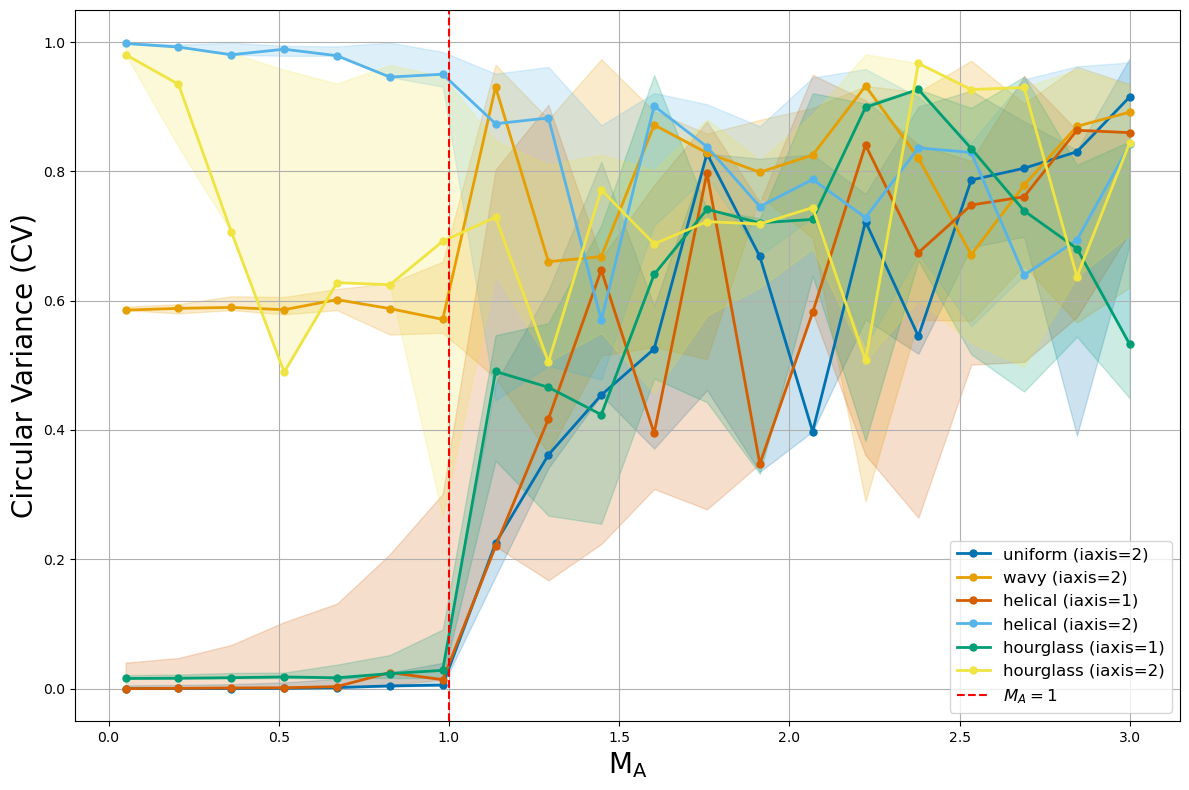

In [7]:
def plot_CV_MA(sstat_data, noise_vals, M_A_vals, geometries):

    geom_iaxis_pairs = [(geom, iaxis)
                        for geom, cfg in geometries.items()
                        for iaxis in cfg['iaxis']]

    colors = ['#0072B2', '#E69F00', '#D55E00', '#56B4E9', '#009E73', '#F0E442']

    plt.figure(figsize=(12, 8))

    for icolor, (geom, iaxis) in zip(colors, geom_iaxis_pairs):

        cv_ref  = []  # reference line: snoise=0
        cv_mins = []  # min across noise levels
        cv_maxs = []  # max across noise levels

        for ima in M_A_vals:
            # reference line at snoise=0
            ref_vals = sstat_data.get((geom, iaxis, noise_vals[0], ima), [])
            cv_ref.append(np.mean(ref_vals) if ref_vals else np.nan)

            # envelope across all noise levels
            all_vals = [np.mean(sstat_data.get((geom, iaxis, snoise, ima), [np.nan]))
                        for snoise in noise_vals]
            cv_mins.append(np.nanmin(all_vals))
            cv_maxs.append(np.nanmax(all_vals))

        cv_ref  = np.array(cv_ref)
        cv_mins = np.array(cv_mins)
        cv_maxs = np.array(cv_maxs)

        plt.plot(M_A_vals, cv_ref, marker='o', color=icolor,
                 linestyle='-', lw=2, ms=5,
                 label=f'{geom} (iaxis={iaxis})')
        plt.fill_between(M_A_vals, cv_mins, cv_maxs, color=icolor, alpha=0.2)
    
    plt.axvline(x=1.0, color='red', linestyle='--', label='$M_A=1$')
    plt.xlabel(r'$\rm M_A$', fontsize=20)
    plt.ylabel('Circular Variance (CV)', fontsize=20)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.grid()
    plt.savefig('CV_vs_MA.pdf', dpi=300)
    plt.show()

plot_CV_MA(sstat_data, NOISE_VALS, M_A_VALS, GEOMETRIES)

# Median(P%)

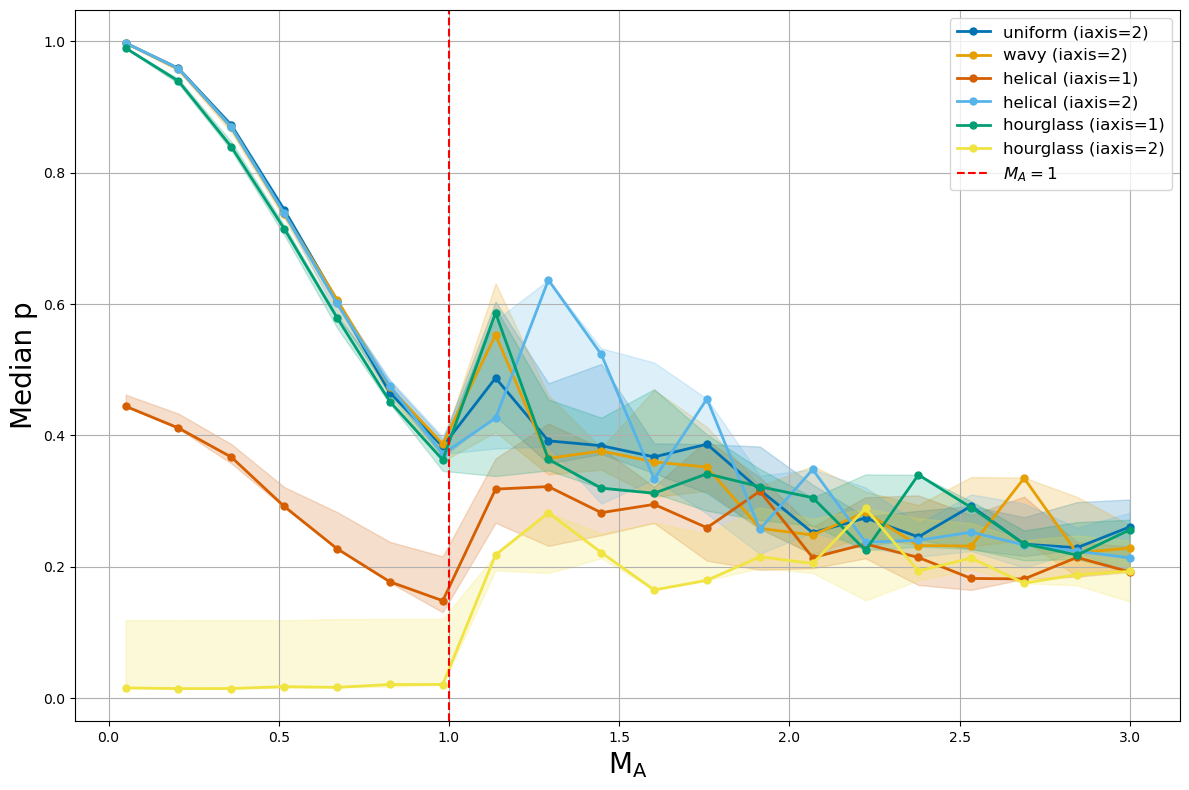

In [8]:
def plot_median_P_MA(median_data, noise_vals, M_A_vals, geometries):

    geom_iaxis_pairs = [(geom, iaxis)
                        for geom, cfg in geometries.items()
                        for iaxis in cfg['iaxis']]

    colors = ['#0072B2', '#E69F00', '#D55E00', '#56B4E9', '#009E73', '#F0E442']

    plt.figure(figsize=(12, 8))

    for icolor, (geom, iaxis) in zip(colors, geom_iaxis_pairs):

        pol_meds_ref  = []
        pol_meds_mins = []
        pol_meds_maxs = []

        for ima in M_A_vals:
            # reference line at snoise=0
            ref_vals = median_data.get((geom, iaxis, noise_vals[0], ima), [])
            pol_meds_ref.append(np.mean(ref_vals) if ref_vals else np.nan)

            # envelope across all noise levels
            all_vals = [np.mean(median_data.get((geom, iaxis, snoise, ima), [np.nan]))
                        for snoise in noise_vals]
            pol_meds_mins.append(np.nanmin(all_vals))
            pol_meds_maxs.append(np.nanmax(all_vals))

        pol_meds_ref  = np.array(pol_meds_ref)
        pol_meds_mins = np.array(pol_meds_mins)
        pol_meds_maxs = np.array(pol_meds_maxs)

        plt.plot(M_A_vals, pol_meds_ref, marker='o', color=icolor,
                 linestyle='-', lw=2, ms=5,
                 label=f'{geom} (iaxis={iaxis})')
        plt.fill_between(M_A_vals, pol_meds_mins, pol_meds_maxs, color=icolor, alpha=0.2)

    plt.axvline(x=1.0, color='red', linestyle='--', label='$M_A=1$')
    plt.xlabel(r'$\rm M_A$', fontsize=20)
    plt.ylabel('Median p', fontsize=20)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.grid()
    plt.savefig('median_P_vs_MA.pdf', dpi=300)
    plt.show()

plot_median_P_MA(median_data, NOISE_VALS, M_A_VALS, GEOMETRIES)

In [ ]:
M_A_VALS  = np.linspace(0.05, 3.0, 10)
g_size=256
pol_meds = []

for imach in M_A_VALS:
    P_Ho2, PHI_Ho2, COS_Ho2 = simulate_field(geometry='hourglass', turbulence='gs95', M_A=imach, iaxis=2, g_size=g_size, anisotropy_strength=1.0, seed=None, snoise = 0.1)
    Pflat = P_Ho2.flatten()
    Pflat = Pflat[Pflat > 0.00000]
    pol_meds.append(np.median(Pflat))

plt.figure(figsize=(8, 6))
plt.plot(M_A_VALS, pol_meds, marker='o')
plt.ylabel('Median Polarization Fraction')
plt.xlabel('$M_A$')
plt.title('Hourglass Axis = 2')
plt.axvline(x=1.0, color='red', linestyle='--', label='$M_A=1$')
plt.grid()
plt.legend()

0.11828411768544086
0.11842531674638779
0.11894512215081549
0.11838252234614569
0.12003539563727589
0.11891623055650317
0.11991229954861095
0.1207818790091926
0.2512938457042584
0.2746093356058836
0.24900804895284734
0.22575031660712425
0.31778821576009547


# Extra: S dispersion exploration

Text(0.5, 1.0, 'Uniform Field')

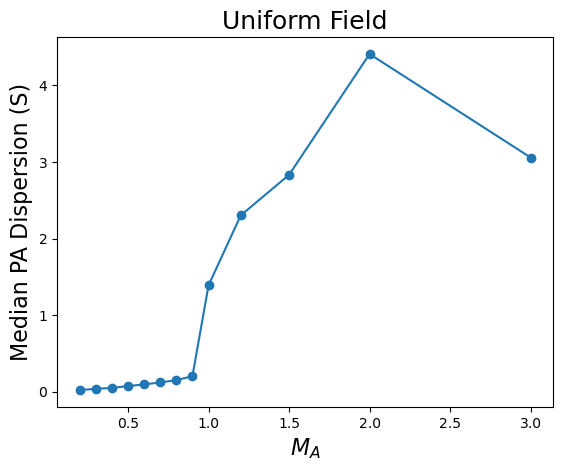

In [ ]:
# mach_vals = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.2, 1.5, 2.0, 3.0]
# g_size = 256
# p_delta = 2
# title = 'Uniform Field'

# S_LIST = []

# for idx, imach in enumerate(mach_vals):
#     P_U,  PHI_U,  COS_U = simulate_field(geometry='uniform', turbulence='gs95', M_A=imach, alpha=np.pi/4, 
#                                              g_size=g_size, anisotropy_strength=1.0, seed=None)
#     S_MAP = compute_S(PHI_U, delta_pixels=p_delta)
#     S_LIST.append(np.median(S_MAP))

# plt.plot(mach_vals, S_LIST, marker='o')
# plt.xlabel(r'$M_A$', fontsize=16)
# plt.ylabel(r'Median PA Dispersion (S)', fontsize=16)
# plt.title(title, fontsize=18)


# # P_U,  PHI_U,  COS_U     = simulate_field(geometry='uniform',   turbulence='gs95', M_A=imach, alpha=np.pi/4, g_size=g_size, anisotropy_strength=1.0, seed=None)
# # P_W,  PHI_W,  COS_W     = simulate_field(geometry='wavy',      turbulence='gs95', M_A=imach,                g_size=g_size, anisotropy_strength=1.0, seed=None)
# # P_He1, PHI_He1, COS_He1 = simulate_field(geometry='helical',   turbulence='gs95', M_A=imach, alpha=0.0,     iaxis=1, g_size=g_size, anisotropy_strength=1.0, seed=None)
# # P_He2, PHI_He2, COS_He2 = simulate_field(geometry='helical',   turbulence='gs95', M_A=imach, alpha=0.0,     iaxis=2, g_size=g_size, anisotropy_strength=1.0, seed=None)
# # P_Ho1, PHI_Ho1, COS_Ho1 = simulate_field(geometry='hourglass', turbulence='gs95', M_A=imach,                iaxis=1, g_size=g_size, anisotropy_strength=1.0, seed=None)
# # P_Ho2, PHI_Ho2, COS_Ho2 = simulate_field(geometry='hourglass', turbulence='gs95', M_A=imach,                iaxis=2, g_size=g_size, anisotropy_strength=1.0, seed=None)



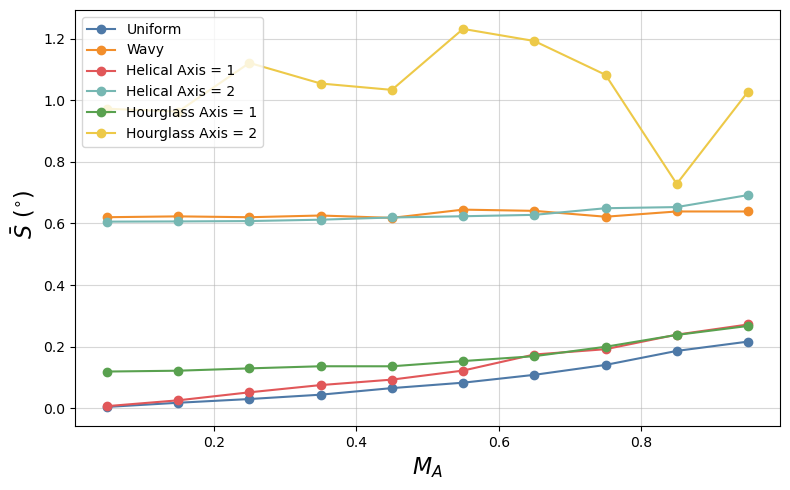

In [ ]:
# # mach_vals = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.2, 1.5, 2.0, 3.0]
# mach_vals = np.linspace(0.05, 0.95, 10)
# g_size  = 256
# p_delta = 2

# geometries = [
#     dict(label='Uniform',         geometry='uniform',   color = '#4E79A7', kwargs=dict(alpha=np.pi/4)),
#     dict(label='Wavy',            geometry='wavy',      color = '#F28E2B', kwargs=dict()),
#     dict(label='Helical Axis = 1',   geometry='helical',   color = '#E15759', kwargs=dict(alpha=0.0, iaxis=1)),
#     dict(label='Helical Axis = 2',   geometry='helical',   color = '#76B7B2', kwargs=dict(alpha=0.0, iaxis=2)),
#     dict(label='Hourglass Axis = 1', geometry='hourglass', color = '#59A14F', kwargs=dict(iaxis=1)),
#     dict(label='Hourglass Axis = 2', geometry='hourglass', color = '#EDC948', kwargs=dict(iaxis=2)),
# ]

# fig, ax = plt.subplots(figsize=(8, 5))

# for geo in geometries:
#     S_LIST = []
#     for imach in mach_vals:
#         _, PHI, _ = simulate_field(geometry=geo['geometry'], turbulence='gs95', M_A=imach, g_size=g_size, 
#                                    anisotropy_strength=1.0, seed=None, **geo['kwargs'])
#         S_MAP = compute_S(PHI, delta_pixels=p_delta)
#         S_LIST.append(np.median(S_MAP))

#     ax.plot(mach_vals, S_LIST, marker='o', label=geo['label'], color=geo['color'])

# ax.set_xlabel(r'$M_A$', fontsize=16)
# ax.set_ylabel(r' $\bar{S}$ ($^{\circ}$)', fontsize=16)
# ax.legend(fontsize=10, loc='upper left')
# plt.tight_layout()
# plt.grid(alpha=0.5)
# plt.show()

4.789325438693719


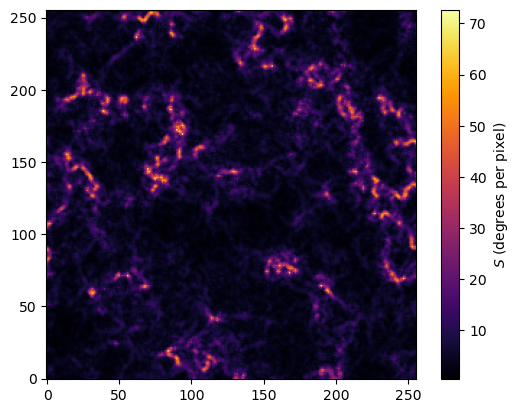

In [ ]:
# plt.imshow(S_MAP, origin='lower', cmap='inferno')
# plt.colorbar(label=r'$S$ (degrees per pixel)')
# print(np.median(S_MAP))

Text(0.5, 1.0, 'Uniform Field, $M_A=5.00$')

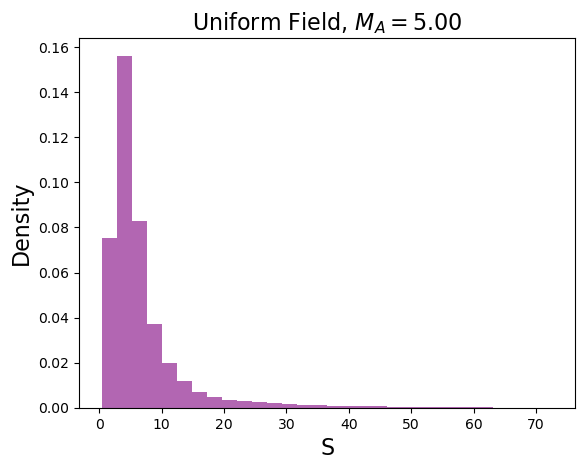

In [ ]:
# plt.hist(S_MAP.flatten(), bins=30, density=True, alpha=0.6, color='purple')
# plt.xlabel('S', fontsize=16)
# plt.ylabel('Density', fontsize=16)
# plt.title(r'Uniform Field, $M_A='f"{imach:.2f}"r'$', fontsize=16)

In [ ]:
# geometries = [
#     dict(label='Uniform',         geometry='uniform',   color = '#4E79A7', kwargs=dict(alpha=np.pi/4)),
#     dict(label='Wavy',            geometry='wavy',      color = '#F28E2B', kwargs=dict()),
#     dict(label='Helical Axis = 1',   geometry='helical',   color = '#E15759', kwargs=dict(alpha=0.0, iaxis=1)),
#     dict(label='Helical Axis = 2',   geometry='helical',   color = '#76B7B2', kwargs=dict(alpha=0.0, iaxis=2)),
#     dict(label='Hourglass Axis = 1', geometry='hourglass', color = '#59A14F', kwargs=dict(iaxis=1)),
#     dict(label='Hourglass Axis = 2', geometry='hourglass', color = '#EDC948', kwargs=dict(iaxis=2)),
# ]

# imach = 0.75

# for geo in geometries:
#     _, PHI, _ = simulate_field(geometry=geo['geometry'], turbulence='gs95', M_A=imach, g_size=g_size, 
#                                 anisotropy_strength=1.0, seed=None, **geo['kwargs'])
#     S_MAP = compute_S(PHI, delta_pixels=p_delta)
#     plt.hist(S_MAP.flatten(), bins=30, density=True, alpha=0.6, color=geo['color'])
#     plt.xlabel('S', fontsize=16)
#     plt.ylabel('Density', fontsize=16)
#     plt.title(r'Uniform Field, $M_A='f"{imach:.2f}"r'$', fontsize=16)

# ax.set_xlabel(r' $\bar{S}$ ($^{\circ}$)', fontsize=16)
# ax.set_ylabel('Density', fontsize=16)
# ax.legend(fontsize=10, loc='upper right')
# plt.tight_layout()
# # plt.grid(alpha=0.5)
# plt.show()